# Day 35 — Gradient Boosting, Stacking & Review

- Explain the intuition behind Gradient Boosting.
- Understand why Gradient Boosting trains predictors sequentially.
- Explain how each new predictor tries to correct previous errors.
- Use `GradientBoostingRegressor` and `GradientBoostingClassifier`.
- Understand `learning_rate`, `n_estimators`, and the trade-off between them.
- Use staged predictions to observe validation performance over boosting stages.
- Apply early stopping with validation data.
- Understand stacking and how a blender/meta-learner combines predictions.
- Review the major ensemble methods.


## 1. Gradient Boosting — core idea

Gradient Boosting builds an ensemble **sequentially**.

Instead of training many independent trees, we train:

1. A first weak learner.
2. Measure its errors/residuals.
3. Train the next learner to reduce those errors.
4. Add the new learner to the ensemble.
5. Repeat.

For regression, a useful simplified intuition is:

> **New tree → learns what the current ensemble is still getting wrong.**

The final prediction is the sum of the contributions from all weak learners.

### Important hyperparameters

| Parameter | Meaning |
|---|---|
| `n_estimators` | Number of boosting stages/trees |
| `learning_rate` | Contribution of each new tree |
| `max_depth` | Complexity of individual trees |
| `subsample` | Fraction of training data used by each stage |

A smaller `learning_rate` usually requires more trees, but can produce a better model when tuned correctly.


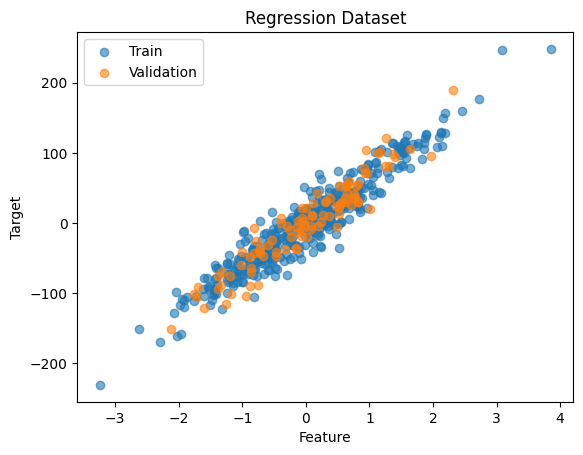

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

X, y = make_regression(
    n_samples=500,
    n_features=1,
    noise=20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.scatter(X_train, y_train, alpha=0.6, label="Train")
plt.scatter(X_val, y_val, alpha=0.6, label="Validation")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Regression Dataset")
plt.legend()
plt.show()


## 2. Basic Gradient Boosting Regressor

`GradientBoostingRegressor` uses decision trees as weak learners.

The important idea is that the trees are **not independent**. Each stage depends on the errors left by earlier stages.


In [2]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gbr.fit(X_train, y_train)

train_pred = gbr.predict(X_train)
val_pred = gbr.predict(X_val)

print("Train RMSE:", mean_squared_error(y_train, train_pred) ** 0.5)
print("Validation RMSE:", mean_squared_error(y_val, val_pred) ** 0.5)


Train RMSE: 18.195818219738793
Validation RMSE: 19.067844504214666


## 3. Visualize the final model

Try changing `n_estimators`, `learning_rate`, and `max_depth`.

Questions:

- What happens when the tree depth increases?
- What happens when the number of estimators becomes very large?
- Can a model with shallow trees still become powerful?


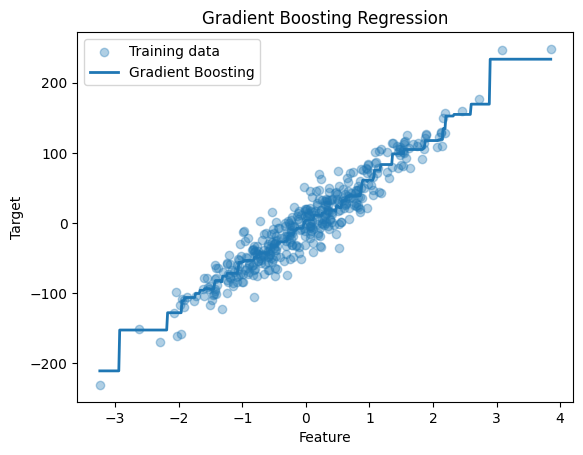

In [3]:
x_grid = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_grid = gbr.predict(x_grid)

plt.scatter(X_train, y_train, alpha=0.35, label="Training data")
plt.plot(x_grid, y_grid, linewidth=2, label="Gradient Boosting")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Gradient Boosting Regression")
plt.legend()
plt.show()


## 4. Staged predictions

One of the most useful ideas in Gradient Boosting is that the ensemble can be inspected **stage by stage**.

`staged_predict()` gives predictions after each boosting stage.

This lets us calculate validation error as more trees are added.

Conceptually:

```text
Tree 1 → prediction
Tree 1 + Tree 2 → prediction
Tree 1 + Tree 2 + Tree 3 → prediction
...
```

This is useful for identifying the point where adding more trees stops improving validation performance.


Best validation stage: 100
Best validation RMSE: 19.067844504214666


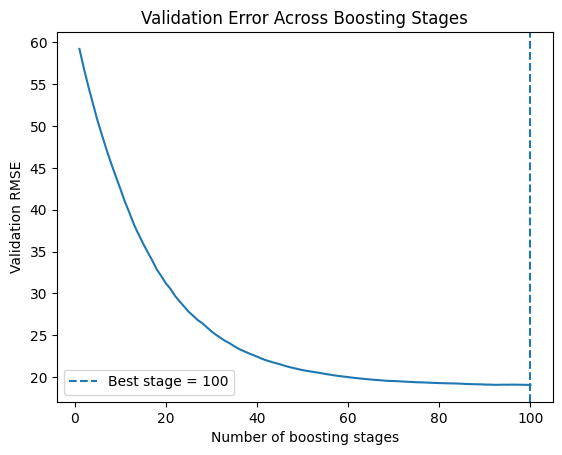

In [4]:
val_errors = [
    mean_squared_error(y_val, y_pred) ** 0.5
    for y_pred in gbr.staged_predict(X_val)
]

best_stage = np.argmin(val_errors) + 1

print("Best validation stage:", best_stage)
print("Best validation RMSE:", min(val_errors))

plt.plot(range(1, len(val_errors) + 1), val_errors)
plt.axvline(best_stage, linestyle="--", label=f"Best stage = {best_stage}")
plt.xlabel("Number of boosting stages")
plt.ylabel("Validation RMSE")
plt.title("Validation Error Across Boosting Stages")
plt.legend()
plt.show()


## 5. Learning rate vs. number of estimators

`learning_rate` controls how strongly each new tree contributes.

### High learning rate
- Each tree has a larger effect.
- Fewer trees may be needed.
- Can converge quickly.
- May overfit or become less stable if too aggressive.

### Low learning rate
- Each tree makes a smaller correction.
- Usually requires more trees.
- Often gives better control over the fitting process.

A common practical strategy is:

> **Try a smaller learning rate and compensate with more estimators, then validate.**


In [5]:
settings = [
    (0.10, 100),
    (0.05, 200),
    (0.01, 500),
]

results = []

for lr, n_est in settings:
    model = GradientBoostingRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=2,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, pred) ** 0.5
    results.append((lr, n_est, rmse))

for lr, n_est, rmse in results:
    print(f"learning_rate={lr:>4}, n_estimators={n_est:>3} -> validation RMSE={rmse:.3f}")


learning_rate= 0.1, n_estimators=100 -> validation RMSE=19.135
learning_rate=0.05, n_estimators=200 -> validation RMSE=19.062
learning_rate=0.01, n_estimators=500 -> validation RMSE=19.048


## 6. Early stopping

Adding more trees does not always improve generalization.

If validation error starts increasing, the model may be overfitting.

One simple early-stopping approach is:

1. Train enough boosting stages.
2. Track validation error after every stage.
3. Find the stage with the lowest validation error.
4. Keep the model at that stage.

Scikit-learn also provides `n_iter_no_change` and `validation_fraction` for automatic early stopping.


In [6]:
early_gbr = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=2,
    validation_fraction=0.2,
    n_iter_no_change=20,
    tol=1e-4,
    random_state=42
)

early_gbr.fit(X_train, y_train)

print("Requested estimators:", 1000)
print("Actually used:", early_gbr.n_estimators_)


Requested estimators: 1000
Actually used: 120


## 7. Gradient Boosting Classification

The same general boosting idea can be used for classification.

We will use a synthetic binary dataset and evaluate accuracy and log loss.


In [7]:
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss

Xc, yc = make_classification(
    n_samples=800,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    class_sep=1.2,
    random_state=42
)

Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gbc.fit(Xc_train, yc_train)

class_pred = gbc.predict(Xc_val)
class_proba = gbc.predict_proba(Xc_val)

print("Validation accuracy:", accuracy_score(yc_val, class_pred))
print("Validation log loss:", log_loss(yc_val, class_proba))


Validation accuracy: 0.975
Validation log loss: 0.06710217536597433


## 8. Staged classification performance

For classification, we can inspect the validation performance as boosting progresses.


Best validation accuracy: 0.975
Best stage: 73


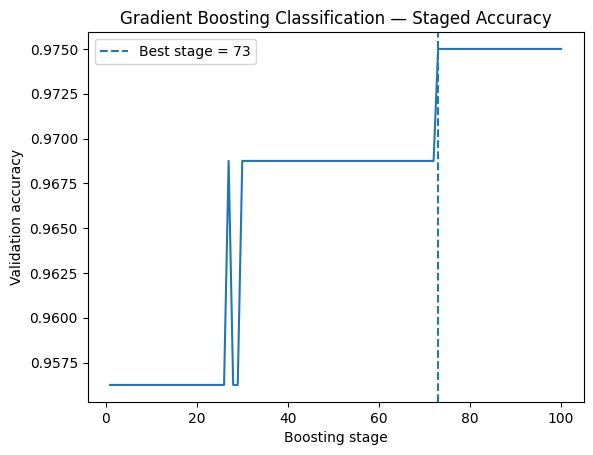

In [8]:
staged_accuracy = []

for pred in gbc.staged_predict(Xc_val):
    staged_accuracy.append(accuracy_score(yc_val, pred))

best_stage_cls = np.argmax(staged_accuracy) + 1

print("Best validation accuracy:", max(staged_accuracy))
print("Best stage:", best_stage_cls)

plt.plot(range(1, len(staged_accuracy) + 1), staged_accuracy)
plt.axvline(best_stage_cls, linestyle="--", label=f"Best stage = {best_stage_cls}")
plt.xlabel("Boosting stage")
plt.ylabel("Validation accuracy")
plt.title("Gradient Boosting Classification — Staged Accuracy")
plt.legend()
plt.show()


## 9. Stacking

**Stacking** combines different models by training another model — called a **blender** or **meta-learner** — on their predictions.

Example:

```text
                 ┌── Random Forest ──┐
Input features ──┼── SVM ────────────┼──> Meta-learner ──> Final prediction
                 └── Logistic Reg. ──┘
```

Unlike simple voting, stacking learns **how much to trust each base predictor**.

A good stacking system normally generates the base-model predictions for the meta-learner using data that the base models did not train on, such as out-of-fold predictions. This helps prevent leakage/overfitting.


In [9]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=100, random_state=42
    )),
    ("svc", SVC(
        probability=True, random_state=42
    ))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_clf.fit(Xc_train, yc_train)

stack_pred = stacking_clf.predict(Xc_val)

print("Stacking validation accuracy:",
      accuracy_score(yc_val, stack_pred))


c:\Users\Puneeth\anaconda3\envs\ml_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Stacking validation accuracy: 0.99375


c:\Users\Puneeth\anaconda3\envs\ml_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Puneeth\anaconda3\envs\ml_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Puneeth\anaconda3\envs\ml_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Puneeth\anaconda3\envs\ml_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was dep

# 10. Chapter 7 Review — Ensemble Learning

## Main ensemble methods

### Voting
Combine different predictors.

- **Hard voting:** majority class wins.
- **Soft voting:** average predicted probabilities.

### Bagging
Train many models independently using bootstrap samples.

- Reduces variance.
- Models can train in parallel.

### Pasting
Similar to bagging, but samples are drawn **without replacement**.

### Random Forest
An ensemble of decision trees using additional randomness.

- Bootstrap samples.
- Random feature selection.
- Strong general-purpose tabular model.

### Extra-Trees
Adds even more randomness to tree construction.

### Random Subspaces
Each predictor receives a random subset of features.

### Random Patches
Random subset of both samples and features.

### Boosting
Train predictors **sequentially**.

Examples:
- AdaBoost
- Gradient Boosting

The next predictor focuses on what previous predictors did poorly.

### Stacking
Different models make predictions, and a meta-learner learns how to combine them.


## 11. AdaBoost vs Gradient Boosting

| Aspect | AdaBoost | Gradient Boosting |
|---|---|---|
| Training | Sequential | Sequential |
| Main idea | Focus more on difficult examples | Fit remaining errors/negative gradient |
| Weak learners | Often shallow trees | Often shallow trees |
| Learning rate | Yes | Yes |
| Can overfit? | Yes | Yes |
| Early stopping | Can be applied through validation/tuning | Commonly used |

### Mental model

**AdaBoost:**
> "Pay more attention to examples the ensemble currently gets wrong."

**Gradient Boosting:**
> "Build the next learner to reduce the current model's loss."


# 12. Final Takeaways

- Ensemble learning combines multiple predictors.
- Bagging mainly reduces variance through independent models.
- Random Forest adds feature randomness to bagged decision trees.
- Boosting builds models sequentially.
- Gradient Boosting adds learners that reduce the remaining loss/errors.
- `learning_rate` controls the size of each correction.
- More estimators + smaller learning rate is a common useful combination.
- Staged predictions show how performance evolves as trees are added.
- Early stopping helps prevent unnecessary fitting and overfitting.
- Stacking uses a meta-learner to combine different base-model predictions.

**Core mental model:**

> Bagging = many independent opinions.  
> Boosting = a sequence of corrections.  
> Stacking = a learner that learns how to combine opinions.
